## New personas creation based on behaviour

In [1]:
from social_graph.analysis import *
from social_graph.pipeline import *
from social_graph.metrics import *

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\magda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
conn3 = sqlite3.connect("data/experiment_set_1/database_server_3.db")
conn4 = sqlite3.connect("data/experiment_set_1/database_server_4.db")
conn5 = sqlite3.connect("data/experiment_set_1/database_server_5.db")

connb1 = sqlite3.connect("data/experiment_set_1/database_server_b1.db")
connb2 = sqlite3.connect("data/experiment_set_1/database_server_b2.db")
connb3 = sqlite3.connect("data/experiment_set_1/database_server_b3.db")

In [3]:
persona_df = pd.read_csv('data/experiment_set_1/persona_df.csv')
persona_df.head()

,Unnamed: 0,id,openness,conscientiousness,extroversion,agreeableness,neuroticism,age,profession,gender,leaning,education_level,persona
0,1,2,consistent/cautious,efficient/organized,solitary/reserved,friendly/compassionate,resilient/confident,young,Skilled_Trades,female,democrat,master,Persona_2
1,2,3,inventive/curious,efficient/organized,outgoing/energetic,friendly/compassionate,sensitive/nervous,old,Skilled_Trades,male,democrat,master,Persona_3
2,3,4,inventive/curious,extravagant/careless,outgoing/energetic,critical/judgmental,sensitive/nervous,young,Science_Academia,female,democrat,master,Persona_4
3,4,5,consistent/cautious,extravagant/careless,solitary/reserved,critical/judgmental,resilient/confident,old,Security,male,democrat,master,Persona_2
4,5,6,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,old,Science_Academia,male,democrat,master,Persona_3


In [4]:
personas = persona_df[['id', 'persona']].rename(columns={'id': 'follower_id'})
personas.head()

,follower_id,persona
0,2,Persona_2
1,3,Persona_3
2,4,Persona_4
3,5,Persona_2
4,6,Persona_3


In [5]:
follow = pd.read_sql("SELECT * FROM follow", conn3)
follow = follow.merge(personas, on='follower_id', how='left')
follow.head()

,user_id,follower_id,id,action,round,persona
0,496,245,1,follow,1,Persona_4
1,743,400,2,follow,1,Persona_3
2,679,743,3,follow,1,Persona_4
3,130,500,4,follow,2,Persona_2
4,825,837,5,follow,2,Persona_1


#### Lifespan

In [6]:
lifespan = lifespan_analysis(follow, agg_by='follower_id')
lifespan.head()

Invalid unfollow action for users 8 -> 342: unfollow
Invalid unfollow action for users 12 -> 333: unfollow
Invalid unfollow action for users 12 -> 679: unfollow
Invalid unfollow action for users 12 -> 690: unfollow
Invalid unfollow action for users 17 -> 32: unfollow
Invalid unfollow action for users 17 -> 323: unfollow
Invalid unfollow action for users 17 -> 341: unfollow
Invalid unfollow action for users 17 -> 500: unfollow
Invalid unfollow action for users 17 -> 914: unfollow
Invalid unfollow action for users 17 -> 934: unfollow
Invalid unfollow action for users 20 -> 109: unfollow
Invalid unfollow action for users 20 -> 819: unfollow
Invalid unfollow action for users 21 -> 459: unfollow
Invalid unfollow action for users 23 -> 21: unfollow
Invalid unfollow action for users 27 -> 21: unfollow
Invalid unfollow action for users 27 -> 152: unfollow
Invalid unfollow action for users 67 -> 502: unfollow
Invalid unfollow action for users 72 -> 679: unfollow
Invalid unfollow action for user

,follower_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate
0,2,3,3,0,NaN,NaN,NaN,1.000000
1,3,4,4,0,NaN,NaN,NaN,1.000000
2,4,1,1,0,NaN,NaN,NaN,1.000000
3,5,1,1,0,NaN,NaN,NaN,1.000000
4,6,51,29,22,10.435606,11.175286,8.145833,0.568627


Why it's only 818 rows while e.g. there's 877 nodes in the largest connective component???

#### Follows

In [7]:
G, G_lcc = create_graph(follow)
local_metrics, summary = calculate_local_metrics(G_lcc)

Number of nodes: 892
Number of edges: 8248
Number of connective components: 16
Components sizes: [877, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Number of nodes (LCC): 877
Number of edges (LCC): 8248


In [8]:
local_metrics.drop(columns=['persona'], inplace=True)
local_metrics.head()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,pagerank,kcore
0,245,69,68,137,0.024745,0.119557,0.006851,31
1,496,44,38,82,0.005516,0.083703,0.004575,31
2,400,61,55,116,0.019681,0.107065,0.006569,31
3,743,38,38,76,0.005583,0.076020,0.003903,31
4,679,128,82,210,0.039603,0.151703,0.011146,31


In [9]:
len(local_metrics[local_metrics['out_degree'] == 0])

72

In [10]:
len(lifespan[lifespan['existing'] == 0])

13

877 - 72 == 818 - 13 so in lifespan table there are only users who have followed any user.

<Axes: >

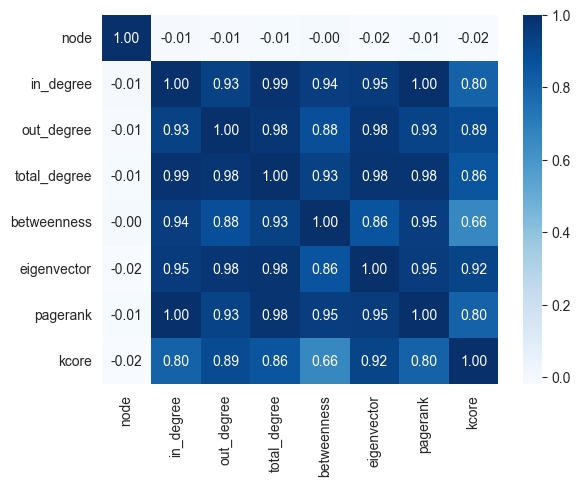

In [11]:
corr = local_metrics.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')

Most of structural metrics is highly correlated. We will keep betweenness and kcore. On the degree-related metrics we will build new features.

#### Posts

In [12]:
posts = pd.read_sql("SELECT * FROM post", conn3)
personas.rename(columns={'follower_id': 'user_id'}, inplace=True)
posts = posts.merge(personas, on='user_id', how='left')
posts.head()

,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,persona
0,1,Hey friends! Just learned about new economic t...,None,17,-1,1,1,None,-1,None,3,Persona_2
1,2,Just analyzed the NBA playoffs schedule & I'm ...,None,411,-1,2,1,None,-1,None,0,Persona_4
2,3,"– @MelissaGardner So do, I saw a sweet post an...",None,411,-1,3,1,None,-1,None,2,Persona_4
3,4,@MelissaGardner I completely agree & what stru...,None,245,2,2,1,None,-1,None,7,Persona_4
4,5,Agree on the value of equality and justice; as...,None,245,1,1,1,None,-1,None,0,Persona_4


In [13]:
posts_summary = posts_analysis(posts)
posts_summary.head()

,user_id,positive_posts,neutral_posts,negative_posts,total_posts,persona
0,2,51,0,9,60,Persona_2
1,3,16,1,0,17,Persona_4
2,4,15,0,0,15,Persona_4
3,5,4,0,0,4,Persona_4
4,6,927,34,22,983,Persona_4


## New personas

In [14]:
local_metrics.rename(columns={'node': 'user_id'}, inplace=True)
lifespan.rename(columns={'follower_id': 'user_id'}, inplace=True)

personas_features = (lifespan.
               merge(local_metrics, on='user_id').
               merge(posts_summary, on='user_id'))

personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,total_degree,betweenness,eigenvector,pagerank,kcore,positive_posts,neutral_posts,negative_posts,total_posts,persona
0,2,3,3,0,NaN,NaN,NaN,1.000000,1,3,4,0.000003,0.006163,0.000296,4,51,0,9,60,Persona_2
1,3,4,4,0,NaN,NaN,NaN,1.000000,0,4,4,0.000000,0.004697,0.000197,4,16,1,0,17,Persona_4
2,4,1,1,0,NaN,NaN,NaN,1.000000,4,1,5,0.000095,0.006068,0.000628,5,15,0,0,15,Persona_4
3,5,1,1,0,NaN,NaN,NaN,1.000000,0,1,1,0.000000,0.000784,0.000197,1,4,0,0,4,Persona_4
4,6,51,29,22,10.435606,11.175286,8.145833,0.568627,58,29,87,0.006935,0.088802,0.005684,31,927,34,22,983,Persona_4


810 rows ????

In [15]:
personas_features.describe()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,total_degree,betweenness,eigenvector,pagerank,kcore,positive_posts,neutral_posts,negative_posts,total_posts
count,810.000000,810.000000,810.000000,810.000000,369.000000,241.000000,369.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000
mean,508.727160,14.967901,10.182716,4.785185,9.087570,10.664895,7.357949,0.872166,10.054321,10.182716,20.237037,0.002193,0.019052,0.001204,9.779012,156.275309,6.318519,8.449383,171.043210
std,289.871287,27.880443,14.583842,14.058795,8.100048,6.387722,8.016346,0.177289,19.186213,14.583842,33.192224,0.005424,0.029539,0.001904,9.460832,328.024374,14.616643,19.169030,356.363402
min,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000006,0.000197,1.000000,1.000000,0.000000,0.000000,1.000000
25%,259.000000,2.000000,2.000000,0.000000,1.416667,6.748585,0.875000,0.751276,1.000000,2.000000,3.000000,0.000014,0.002466,0.000306,3.000000,20.000000,0.000000,0.000000,21.000000
50%,509.500000,5.000000,4.000000,0.000000,9.000000,11.229964,5.520833,1.000000,3.000000,4.000000,7.000000,0.000310,0.006205,0.000510,6.000000,43.000000,1.000000,2.000000,47.000000
75%,759.750000,13.000000,11.000000,2.000000,13.786458,13.649934,10.708333,1.000000,9.000000,11.000000,19.000000,0.001725,0.019505,0.001053,13.000000,118.000000,5.000000,7.000000,127.750000
max,1001.000000,224.000000,93.000000,131.000000,46.458333,37.240957,46.458333,1.000000,148.000000,93.000000,241.000000,0.052766,0.168213,0.014656,31.000000,2882.000000,137.000000,191.000000,3133.000000


### Feature engineering

In [16]:
days = 60

In [17]:
posts_columns = ['positive_posts', 'neutral_posts', 'negative_posts']

for column in posts_columns:
    personas_features[column + '_ratio'] = personas_features[column] / personas_features['total_posts']

personas_features['posts_per_day'] = personas_features['total_posts'] / days

In [18]:
personas_features['in_out_degree_ratio'] = personas_features['in_degree'] / (personas_features['out_degree'] + 1)

In [19]:
personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,positive_posts,neutral_posts,negative_posts,total_posts,persona,positive_posts_ratio,neutral_posts_ratio,negative_posts_ratio,posts_per_day,in_out_degree_ratio
0,2,3,3,0,NaN,NaN,NaN,1.000000,1,3,...,51,0,9,60,Persona_2,0.850000,0.000000,0.15000,1.000000,0.250000
1,3,4,4,0,NaN,NaN,NaN,1.000000,0,4,...,16,1,0,17,Persona_4,0.941176,0.058824,0.00000,0.283333,0.000000
2,4,1,1,0,NaN,NaN,NaN,1.000000,4,1,...,15,0,0,15,Persona_4,1.000000,0.000000,0.00000,0.250000,2.000000
3,5,1,1,0,NaN,NaN,NaN,1.000000,0,1,...,4,0,0,4,Persona_4,1.000000,0.000000,0.00000,0.066667,0.000000
4,6,51,29,22,10.435606,11.175286,8.145833,0.568627,58,29,...,927,34,22,983,Persona_4,0.943032,0.034588,0.02238,16.383333,1.933333


In [20]:
selected_features = personas_features[['user_id', 'persona', 'in_out_degree_ratio', 'betweenness', 'kcore',
                    'neutral_posts_ratio', 'negative_posts_ratio', 'posts_per_day', 'lifespan_median', 'survival_rate']]

selected_features.set_index('user_id', inplace=True)
selected_features.head()

,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate
user_id,,,,,,,,,
2,Persona_2,0.250000,0.000003,4,0.000000,0.15000,1.000000,NaN,1.000000
3,Persona_4,0.000000,0.000000,4,0.058824,0.00000,0.283333,NaN,1.000000
4,Persona_4,2.000000,0.000095,5,0.000000,0.00000,0.250000,NaN,1.000000
5,Persona_4,0.000000,0.000000,1,0.000000,0.00000,0.066667,NaN,1.000000
6,Persona_4,1.933333,0.006935,31,0.034588,0.02238,16.383333,8.145833,0.568627


Handle skew - Apply log to heavy-tailed features.

In [21]:
selected_features['posts_per_day'] = np.log1p(selected_features['posts_per_day'])
# selected_features['total_degree'] = np.log1p(selected_features['total_degree'])
selected_features['betweenness'] = np.log1p(selected_features['betweenness'])

C:\Users\magda\AppData\Local\Temp\ipykernel_3280\4267658400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['posts_per_day'] = np.log1p(selected_features['posts_per_day'])
C:\Users\magda\AppData\Local\Temp\ipykernel_3280\4267658400.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['betweenness'] = np.log1p(selected_features['betweenness'])


<Axes: >

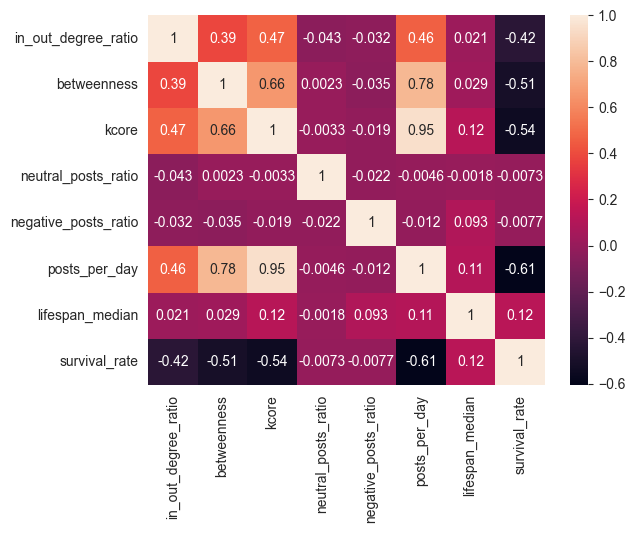

In [22]:
corr = selected_features.drop(columns=['persona'], inplace=False).corr()
sns.heatmap(corr, annot=True)

We keep these features.

In [23]:
from sklearn.preprocessing import StandardScaler

features_scaled = selected_features.copy().drop(columns=['persona'])

# Fill Nan in lifespan_median with zeros.
features_scaled['lifespan_median'].fillna(0, inplace=True)

features_scaled = StandardScaler().fit_transform(features_scaled)

C:\Users\magda\AppData\Local\Temp\ipykernel_3280\4142756251.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features_scaled['lifespan_median'].fillna(0, inplace=True)


### Clustering

#### KMeans

k=2 silhouette=0.3944
k=3 silhouette=0.3426
k=4 silhouette=0.3239
k=5 silhouette=0.2122
k=6 silhouette=0.2505
k=7 silhouette=0.2685
k=8 silhouette=0.2636
k=9 silhouette=0.2553


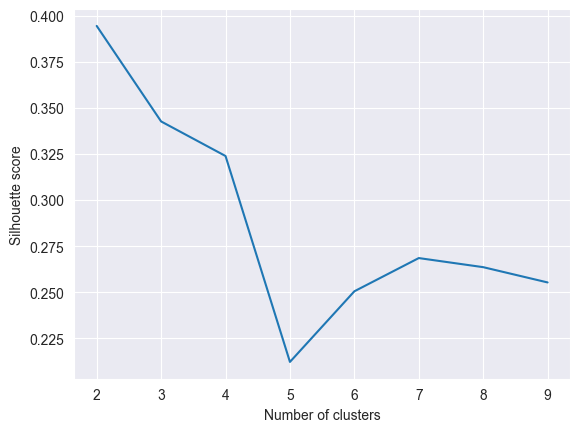

In [48]:
search_best_number_of_personae(features_scaled)

Although the silhouette score is maximized at k=2, this solution yields overly coarse clusters that obscure meaningful behavioral distinctions. Solutions with k=3 and k=4 provide slightly lower silhouette values but reveal richer and more interpretable structure, including distinct groups of highly central actors, stable core users, and peripheral participants. Therefore, k=4 is selected as a balance between cluster quality and interpretability.

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(features_scaled)

In [25]:
selected_features['kmeans_label'] = labels
selected_features.head()

C:\Users\magda\AppData\Local\Temp\ipykernel_3280\499104692.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['kmeans_label'] = labels


,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate,kmeans_label
user_id,,,,,,,,,,
2,Persona_2,0.250000,0.000003,4,0.000000,0.15000,0.693147,NaN,1.000000,1
3,Persona_4,0.000000,0.000000,4,0.058824,0.00000,0.249461,NaN,1.000000,0
4,Persona_4,2.000000,0.000095,5,0.000000,0.00000,0.223144,NaN,1.000000,0
5,Persona_4,0.000000,0.000000,1,0.000000,0.00000,0.064539,NaN,1.000000,0
6,Persona_4,1.933333,0.006911,31,0.034588,0.02238,2.855512,8.145833,0.568627,3


In [26]:
selected_features['kmeans_label'].value_counts()

kmeans_label
0    487
2    182
1     76
3     65
Name: count, dtype: int64

In [27]:
selected_features.drop(columns=['kmeans_label'], inplace=False).groupby('persona').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate
persona,,,,,,,,
Persona_1,0.677723,0.002284,9.453815,0.037831,0.056748,0.851829,7.488809,0.855216
Persona_2,0.644945,0.001951,9.502646,0.032146,0.051971,0.844914,6.718137,0.887004
Persona_3,0.682480,0.002373,10.470297,0.032812,0.055504,0.929038,7.568118,0.879022
Persona_4,0.666408,0.002034,9.741176,0.040880,0.047911,0.863904,7.626126,0.872351


In [28]:
selected_features.drop(columns=['persona'], inplace=False).groupby('kmeans_label').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate
kmeans_label,,,,,,,,
0,0.542143,0.000480,5.018480,0.034853,0.027204,0.474996,1.036560,0.951835
1,0.425742,0.000380,4.460526,0.041045,0.235323,0.448480,5.262897,0.924318
2,0.894315,0.002425,17.230769,0.035286,0.048431,1.380073,11.164134,0.747719
3,1.271580,0.016289,30.800000,0.039358,0.051725,2.919116,7.355769,0.562738


**Comment:**
- New clusters are much more structured, old personas look almost flat/random.
- old personas are very similar across features, only small differences. Personas are weakly separable in behavior.

**New personas:**
- Cluster 0 — Peripheral stable - Passive but persistent
- Cluster 1 — Unstable / negative actors - Emotionally negative but not central, the only cluster clearly separated by sentiment
- Cluster 2 — Core stable actors - Strong, embedded, long-lasting participants
- Cluster 3 — Super hubs / elites - Extremely active, central, but unstable

The original personas show minimal differentiation in structural and behavioral features, suggesting they do not strongly influence network dynamics. In contrast, clustering based on empirical features reveals distinct behavioral archetypes, including highly central but unstable hubs, stable core participants, peripheral passive users, and sentiment-driven actors. This indicates that emergent behavior in the system is better explained by structural and activity-based features than by predefined persona labels. Moreover, clusters counts seem sensible.

Behavior ≠ persona design

<Axes: xlabel='kmeans_label', ylabel='persona'>

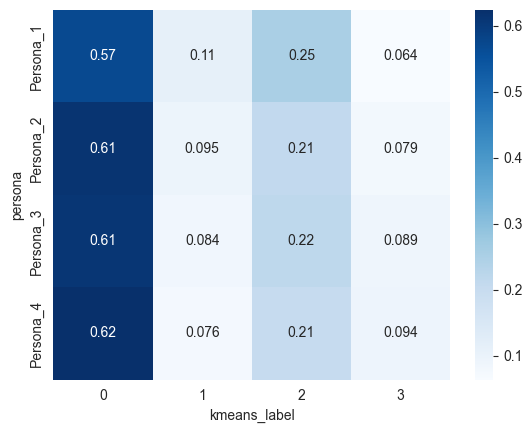

In [29]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='index')
sns.heatmap(tab, annot=True, cmap='Blues')

<Axes: xlabel='kmeans_label', ylabel='persona'>

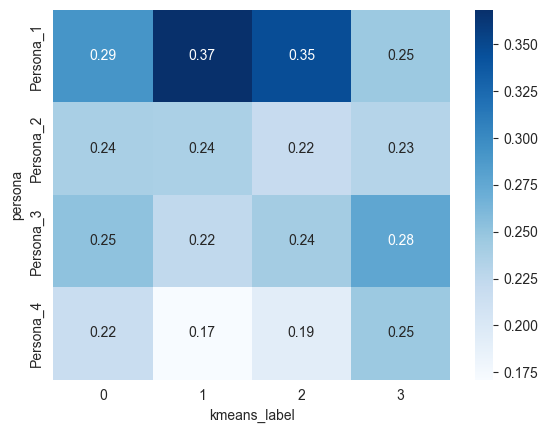

In [30]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

In [31]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(selected_features['persona'], selected_features['kmeans_label'])

-0.003490020824521587

**Value close to 0 means random** - There is essentially no alignment between old personas and new clusters. Even though agents were assigned personas, their network position and activity patterns evolved independently.

The Adjusted Rand Index close to zero and the lack of structure in the contingency tables indicate that the clustering results are statistically independent from the predefined personas. This suggests that the original persona assignment does not meaningfully explain differences in structural position, activity, or interaction behavior within the network. Instead, the observed behavioral patterns appear to emerge from the dynamics of the system rather than from the imposed persona categories.

personas = top-down design

clusters = bottom-up emergence

Result shows:

bottom-up structure dominates

#### Hierarchical clustering

KMeans forces spherical clusters. Hierarchical clustering lets structure emerge naturally. It’s often much more interpretable for this kind of data.

In [32]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=4,          # same as KMeans for comparison
    linkage='ward'         # best default
    # linkage='average'   # more flexible
    # linkage='complete'  # tighter clusters
)

labels = model.fit_predict(features_scaled)

selected_features['hier_label'] = labels

C:\Users\magda\AppData\Local\Temp\ipykernel_3280\2511081372.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['hier_label'] = labels


In [33]:
selected_features['hier_label'].value_counts()

hier_label
0    408
2    218
1    128
3     56
Name: count, dtype: int64

In [34]:
selected_features.drop(columns=['persona', 'kmeans_label'], inplace=False).groupby('hier_label').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_median,survival_rate
hier_label,,,,,,,,
0,0.545020,0.000395,4.610294,0.019411,0.058681,0.447169,0.943333,0.989010
1,1.100407,0.010203,28.703125,0.037379,0.049458,2.434928,8.135091,0.653654
2,0.711139,0.001272,9.880734,0.033850,0.048709,0.892952,7.717374,0.752620
3,0.420526,0.000324,3.785714,0.160533,0.043189,0.313288,3.531250,0.985712


New clusters:

- Cluster 0 — Passive & extremely stable (“lurkers”) - Users that barely engage but almost never churn
- Cluster 1 — Elite hubs / dominant actors - Highly central, very active, but unstable
- Cluster 2 — Core balanced users - Healthy, stable core of the network
- Cluster 3 — Emotionally distinct / low-structure users - Low-activity, low-structure, but content-distinct group, only cluster clearly separated by content (not structure)

Hierarchical clustering reveals a more nuanced structure than KMeans by separating low-activity users into distinct subgroups based on content characteristics.

<Axes: xlabel='hier_label', ylabel='persona'>

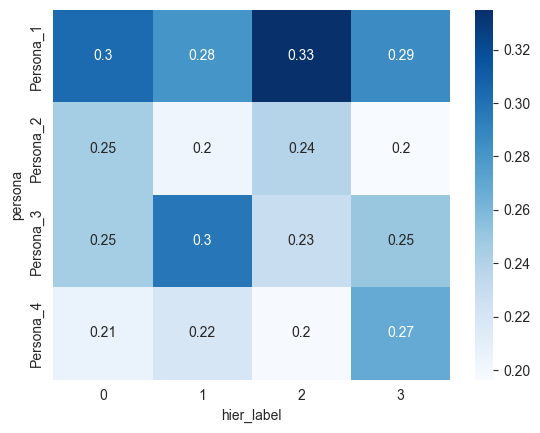

In [38]:
tab = pd.crosstab(selected_features['persona'], selected_features['hier_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

As before it's random mixing.

<Axes: xlabel='hier_label', ylabel='kmeans_label'>

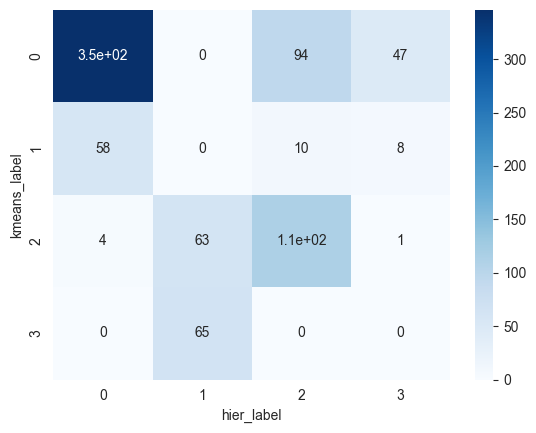

In [43]:
tab = pd.crosstab(selected_features['kmeans_label'], selected_features['hier_label'])#, normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

In [36]:
print(f"Adjusted rand score:\nold persona vs. hierarchical clustering: {adjusted_rand_score(selected_features['persona'], selected_features['hier_label'])}")
print(f"KMeans vs. hierarchical clustering: {adjusted_rand_score(selected_features['kmeans_label'], selected_features['hier_label'])}")

Adjusted rand score:
old persona vs. hierarchical clustering: -0.0011708344167097244
KMeans vs. hierarchical clustering: 0.3534671147211139


There are some relations across new labels. Hierarchical clustering captures some similar structure as KMeans, but refines it differently.

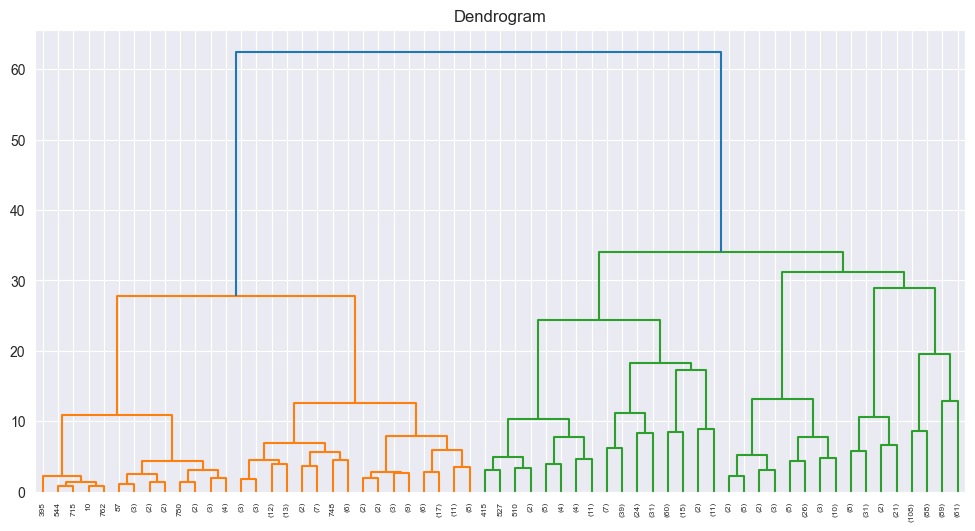

In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(features_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.show()

Choosing number of clusters - cut by distance threshold

In [47]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=20, criterion='distance')
selected_features['hier_cluster'] = clusters

selected_features['hier_cluster'].value_counts()

C:\Users\magda\AppData\Local\Temp\ipykernel_3280\1279447590.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['hier_cluster'] = clusters


hier_cluster
7    346
4    189
2    105
6     62
5     56
3     29
1     23
Name: count, dtype: int64

It's too much group.